Лабораторная работа №5 (Измерение лямбда ритмов)

Касьяненко Вера и Кремпольская Екатерина

P3420

Импорт необходимых библиотек:

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, butter, filtfilt

from IPython.display import display

plt.rcParams["figure.dpi"] = 120

Загрузка наших изменений.



1. Просмотр видео
2. Слежение глазами
3. Чтение чисел на экране
4. Игра в визуальную новеллу



In [ ]:
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1JJ20NRuLOTXk3RO8aurxEhYKEJ_9gVz1' -O 1.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=17axyZ5RVB4kQSr7MvlJOm5H6Q8lc90me' -O 2.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1br5s7Ne_DI88lillsJ9h1kB7pjsTrRbE' -O 3.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1oiI2N5_o24ZZamBw9Gwot1uyU_gQoriq' -O 4.csv

In [ ]:
CONDITIONS = [
    ("Просмотр видео", "1.csv"),
    ("Слежение глазами", "2.csv"),
    ("Чтение", "3.csv"),
    ("Игра", "4.csv"),
]

fs_default = 250.0

# Полосы частот
lambda_band_hz = (4.0, 6.0)
total_band_hz  = (1.0, 40.0)

PREFER_COL = "A0 (В)"

## Чтение сигнала из CSV

In [ ]:
# Оценка Fs по времени + чтение CSV
def _estimate_fs_from_time(t: np.ndarray) -> float | None:
    t = np.asarray(t, dtype=float)
    t = t[np.isfinite(t)]
    if t.size < 3:
        return None

    # сортируем + убираем дубли времени
    t = np.unique(np.sort(t))
    dt = np.diff(t)
    dt = dt[dt > 0]
    if dt.size == 0:
        return None

    return float(1.0 / np.median(dt))


def read_signal_from_csv(path: str, fs_fallback: float = 250.0, prefer_col: str | None = None):
    df = pd.read_csv(path)

    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

    time_col = None
    for cand in ["Время (с)", "time", "Time", "t", "timestamp"]:
        if cand in df.columns and pd.api.types.is_numeric_dtype(df[cand]):
            time_col = cand
            break

    if prefer_col is not None and prefer_col in df.columns and pd.api.types.is_numeric_dtype(df[prefer_col]):
        sig_col = prefer_col
    else:
        sig_col = numeric_cols[1] if len(numeric_cols) > 1 else numeric_cols[0]

    # Сигнал
    x = df[sig_col].dropna().astype(float).to_numpy()

    # Частота дискретизации
    fs = fs_fallback
    if time_col is not None:
        t = df[time_col].dropna().astype(float).to_numpy()
        fs_est = _estimate_fs_from_time(t)
        if fs_est is not None and np.isfinite(fs_est) and fs_est > 0:
            fs = fs_est
    return x, sig_col, fs


## PSD (Welch) и мощность в полосе

- считаем PSD методом Welch,
- считаем мощность в:
  - lambda (4-6 Гц),
  - общей полосе (1-40 Гц),
- считаем относительную мощность lambda (доля от общей)


In [ ]:
# PSD + мощности
def psd_welch(x: np.ndarray, fs: float, nperseg: int = 1024):
    x = np.asarray(x, dtype=float)

    x = x - np.mean(x)

    nperseg = int(min(nperseg, len(x)))
    f, pxx = welch(x, fs=fs, nperseg=nperseg)
    return f, pxx


def band_power(f: np.ndarray, pxx: np.ndarray, band: tuple[float, float]) -> float:
    lo, hi = band
    m = (f >= lo) & (f <= hi)
    if not np.any(m):
        return 0.0
    return float(np.trapezoid(pxx[m], f[m]))

## Lambda-фильтр (4-6 Гц)


In [ ]:
# Полосовой фильтр 4-6 Гц
def lambda_filter(x: np.ndarray, fs: float, band=(4.0, 6.0), order: int = 4):
    x = np.asarray(x, dtype=float)
    nyq = 0.5 * fs
    lo, hi = band
    hi = min(hi, nyq * 0.99)

    b, a = butter(order, [lo/nyq, hi/nyq], btype="band")
    return filtfilt(b, a, x)


## Графики

1) первые 10 секунд исходного сигнала;
2) PSD с выделением lambda-полосы;
3) сравнение первых 10 секунд: исходный сигнал и lambda-фильтр


In [ ]:
# Графики
def plot_raw_blocks(x: np.ndarray, fs: float, title: str):
    n = len(x)
    t = np.arange(n) / fs

    fig, ax = plt.subplots(figsize=(10, 6))
    n10 = min(n, int(10 * fs))

    ax.plot(t[:n10], x[:n10], linewidth=0.8)
    ax.set_title(f"{title} - исходный сигнал")
    ax.set_xlabel("время, c")
    ax.set_ylabel("амплитуда")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_psd_lambda(x: np.ndarray, fs: float, title: str):
    f, pxx = psd_welch(x, fs=fs)
    p_l = band_power(f, pxx, lambda_band_hz)

    t_hi = min(total_band_hz[1], float(np.max(f)))
    p_tot = band_power(f, pxx, (total_band_hz[0], t_hi))
    p_rel = (p_l / p_tot) if p_tot > 0 else 0.0

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(f, pxx, linewidth=1.2)
    ax.axvspan(lambda_band_hz[0], lambda_band_hz[1], alpha=0.2,
               label=f"lambda {lambda_band_hz[0]}-{lambda_band_hz[1]} Гц")
    ax.set_xlim(0, 30)
    ax.set_title(f"{title} - PSD (Welch)")
    ax.set_xlabel("частота, Гц")
    ax.set_ylabel("PSD")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return {
        "p_lambda": float(p_l),
        "p_lambda_rel": float(p_rel),
        "p_total": float(p_tot),
        "freqs": f,
        "psd": pxx,
    }


def plot_lambda_time(x: np.ndarray, fs: float, title: str):
    x_l = lambda_filter(x, fs, band=lambda_band_hz, order=4)
    t = np.arange(len(x_l)) / fs

    fig, ax = plt.subplots(figsize=(12, 6))

    show = min(len(x), int(10 * fs))
    ax.plot(t[:show], x[:show], label="исходный", linewidth=0.8, alpha=0.75)
    ax.plot(t[:show], x_l[:show], label="lambda (4-6 Гц)", linewidth=1.1)

    ax.set_title(f"{title} - исходный vs lambda")
    ax.set_xlabel("время, c")
    ax.set_ylabel("амплитуда")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

    stats = {
        "средняя_амплитуда": float(np.mean(np.abs(x_l))),
        "std_амплитуда": float(np.std(x_l)),
        "макс_амплитуда": float(np.max(np.abs(x_l))),
    }
    return x_l, stats


## Запуск по всем условиям

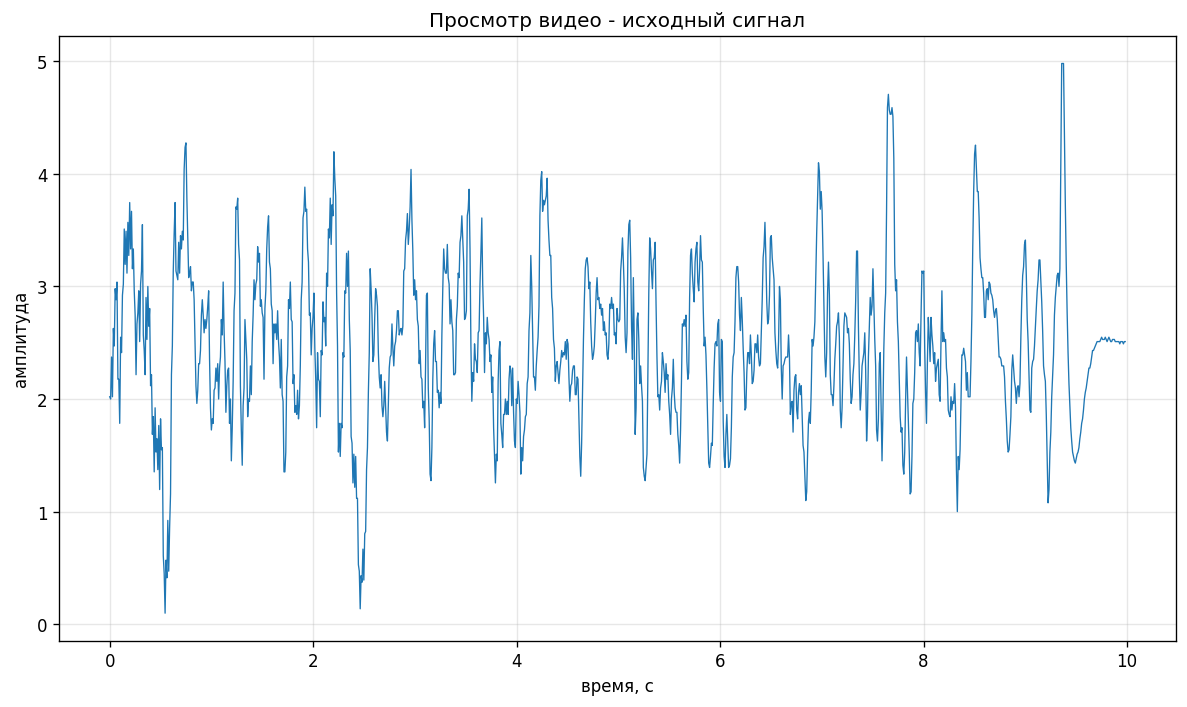

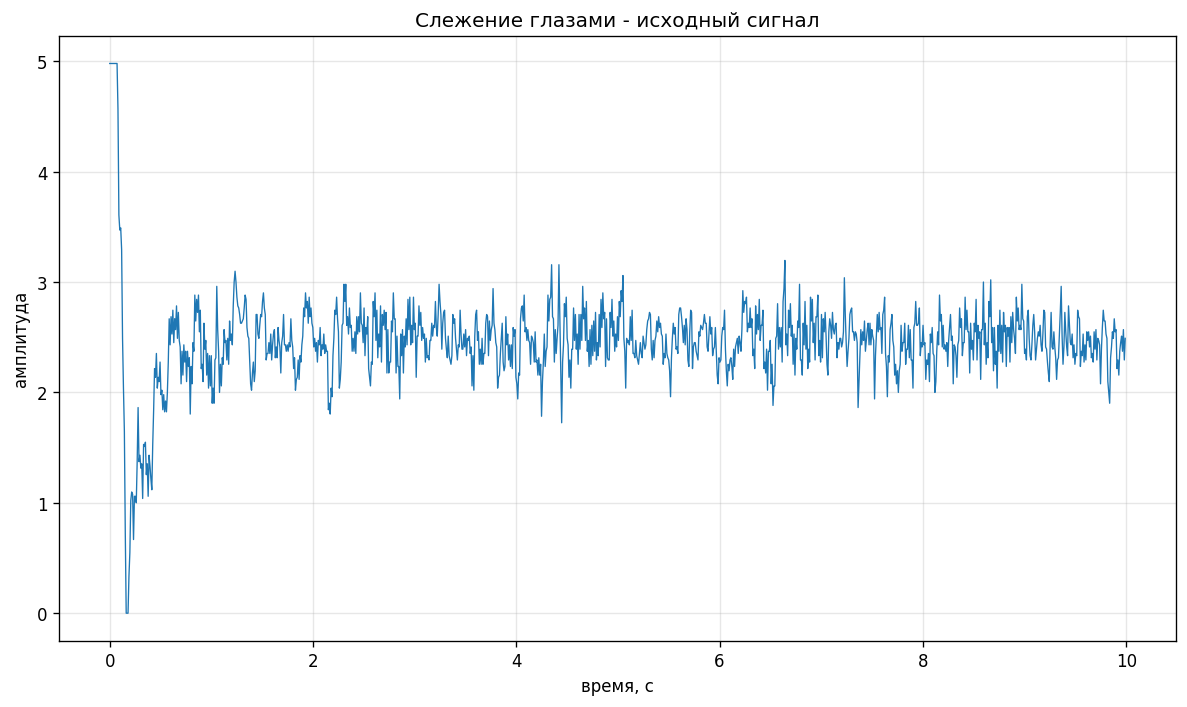

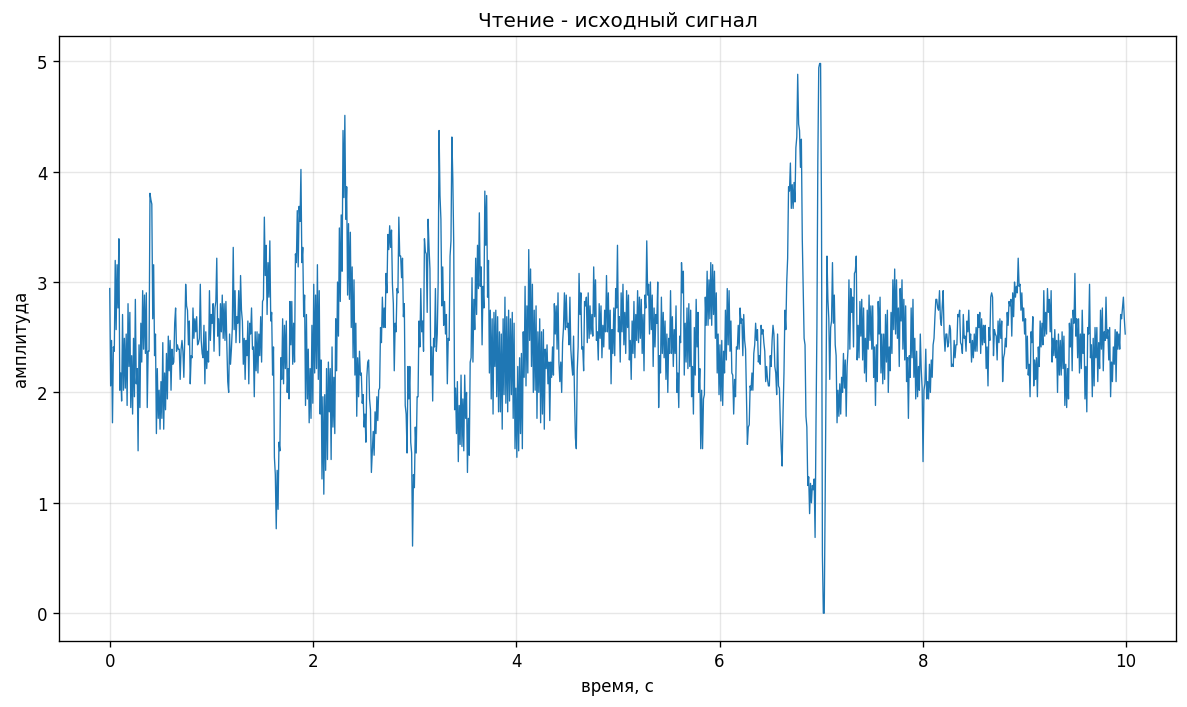

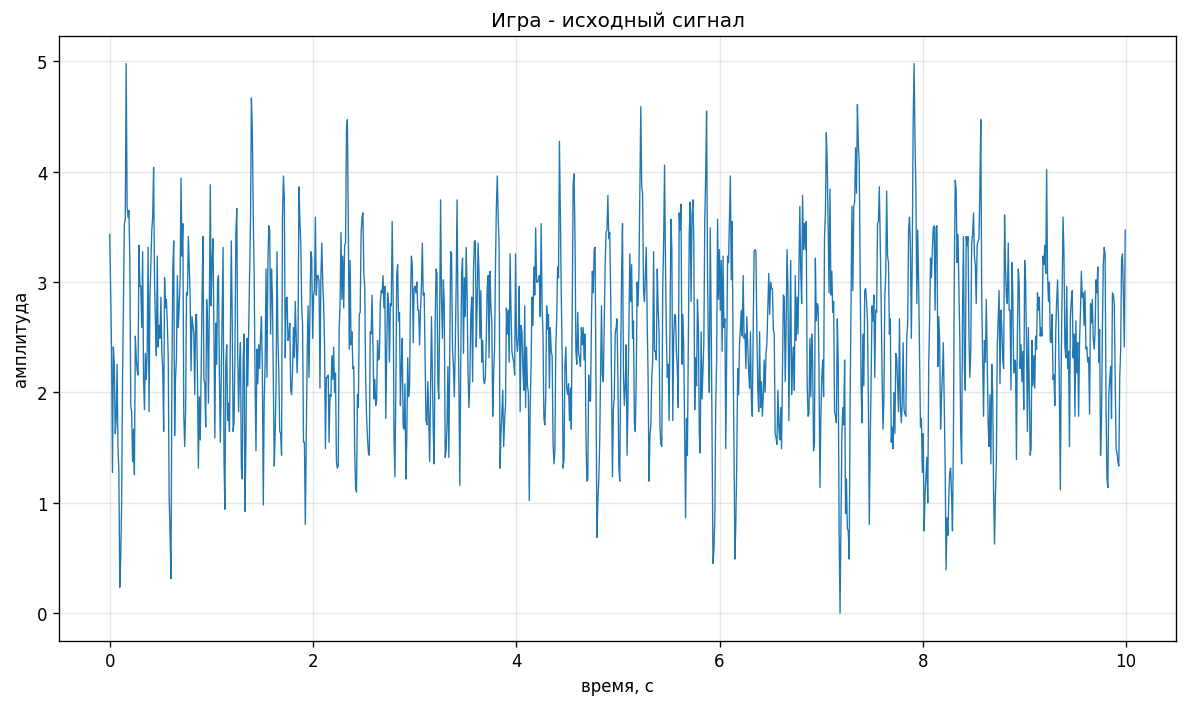

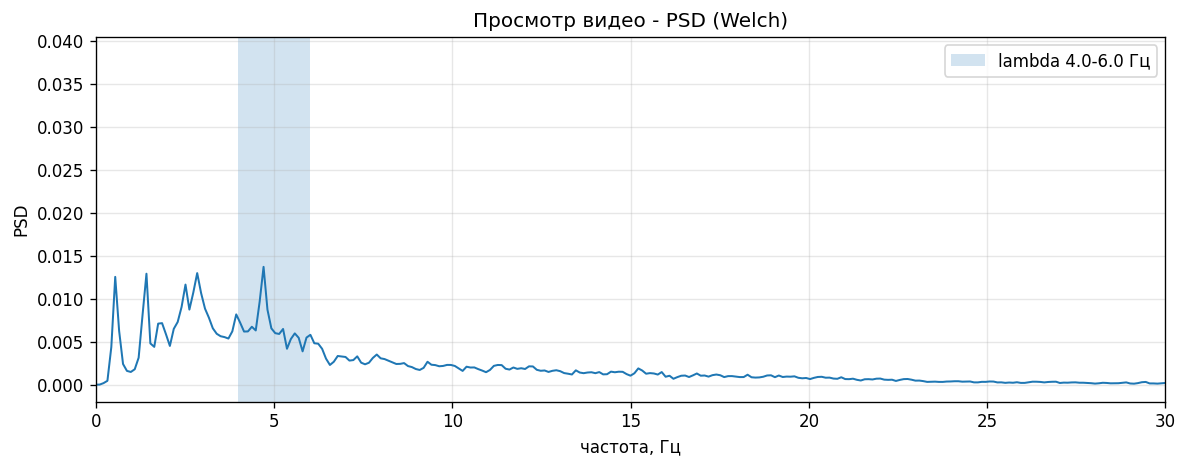

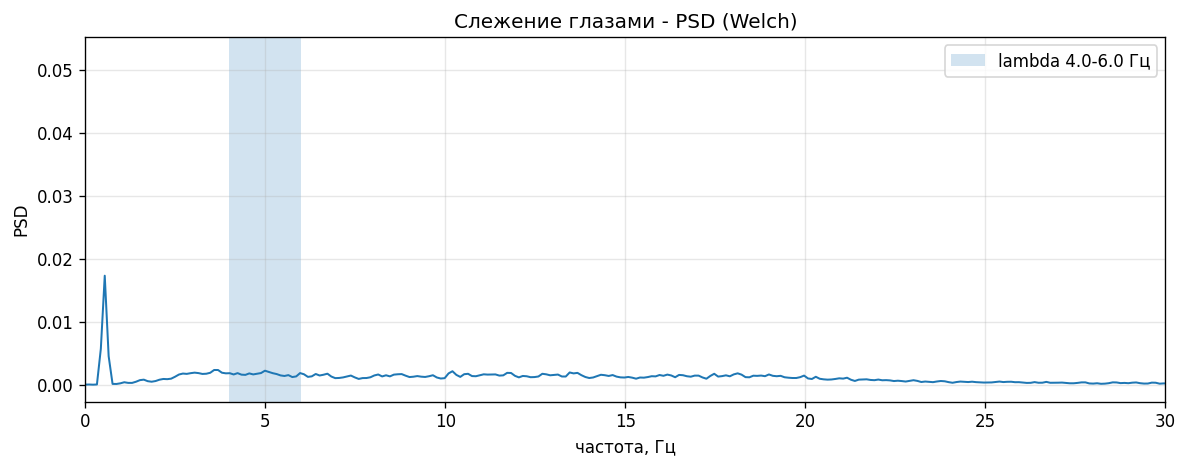

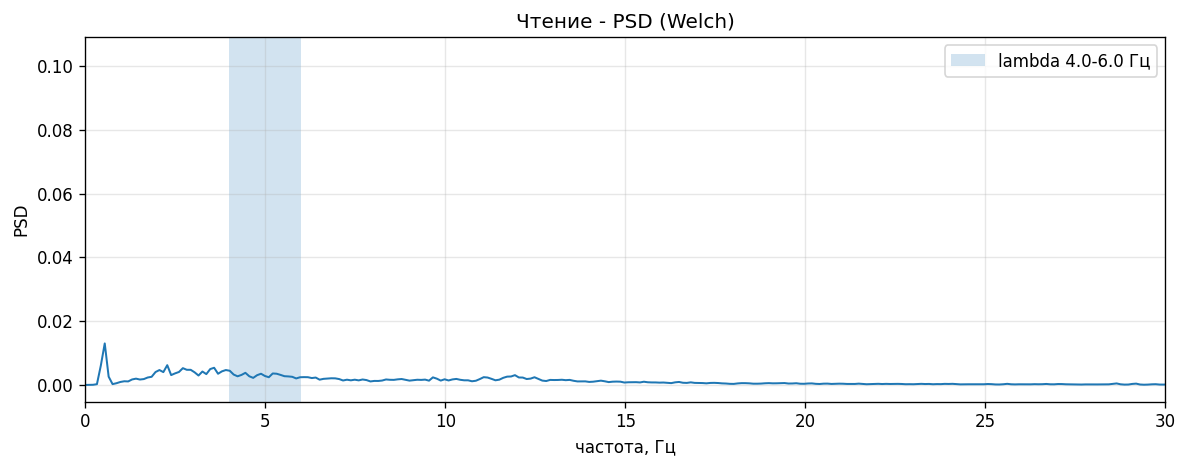

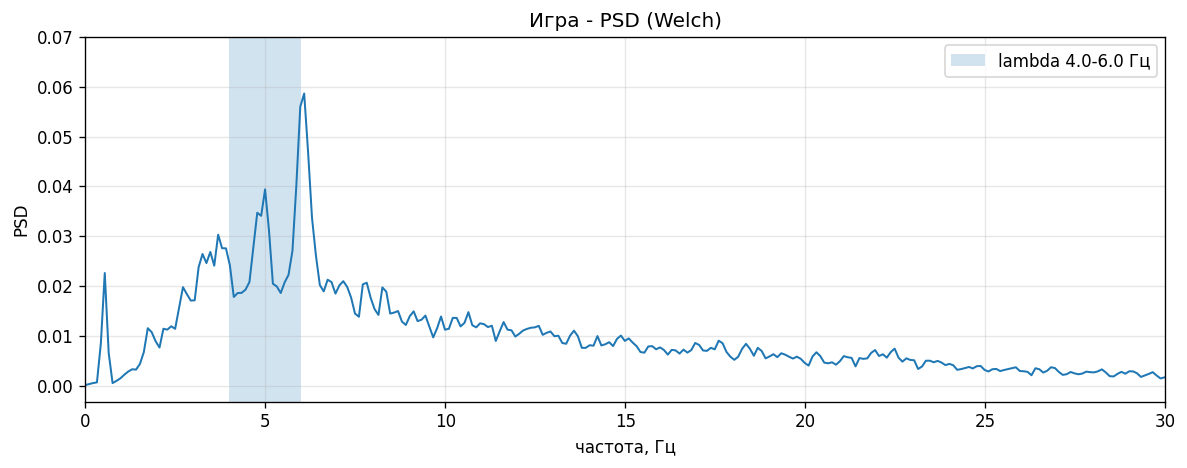

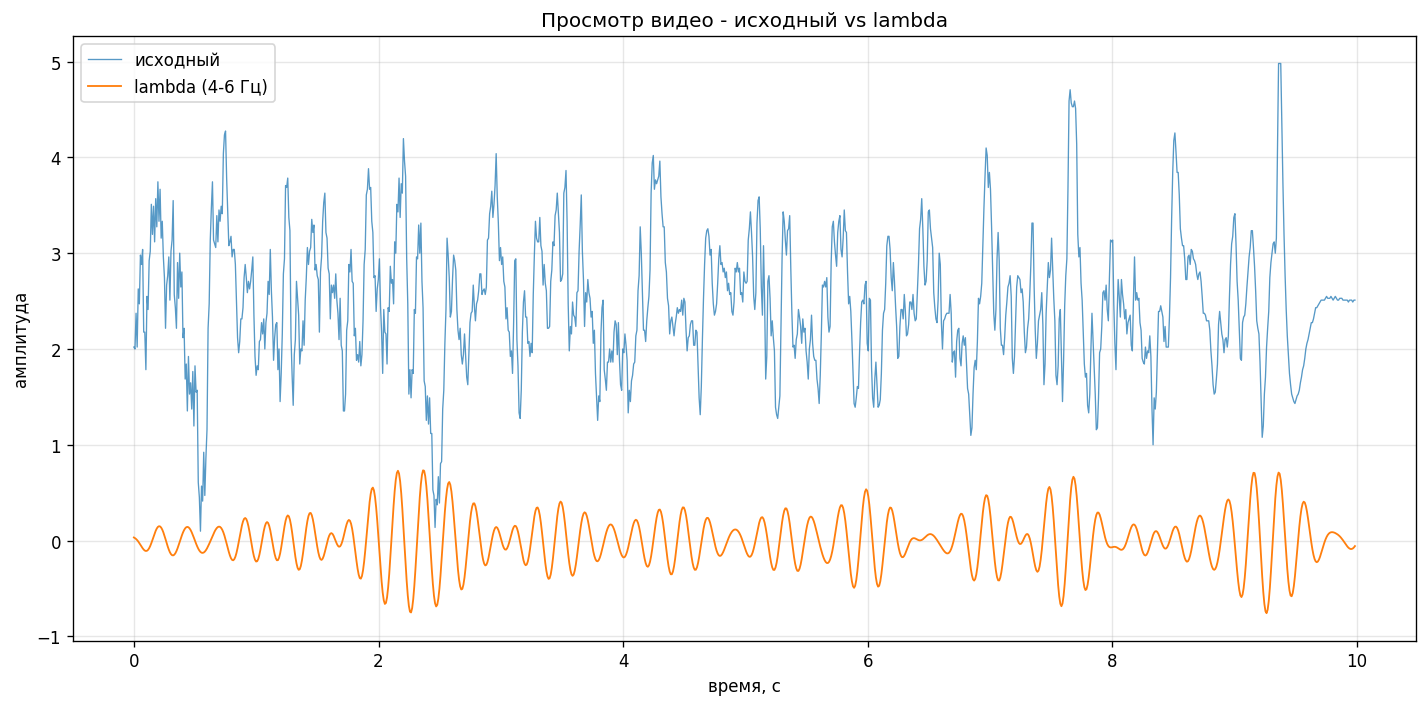

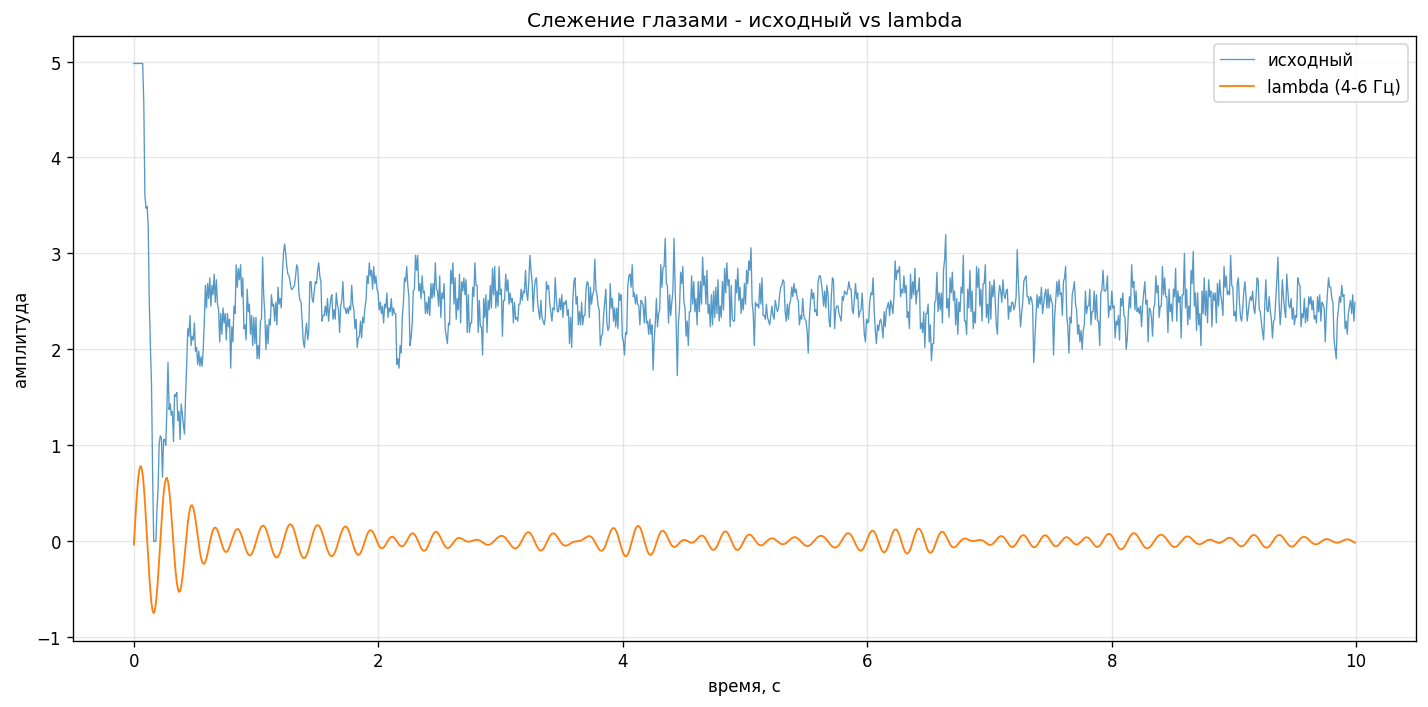

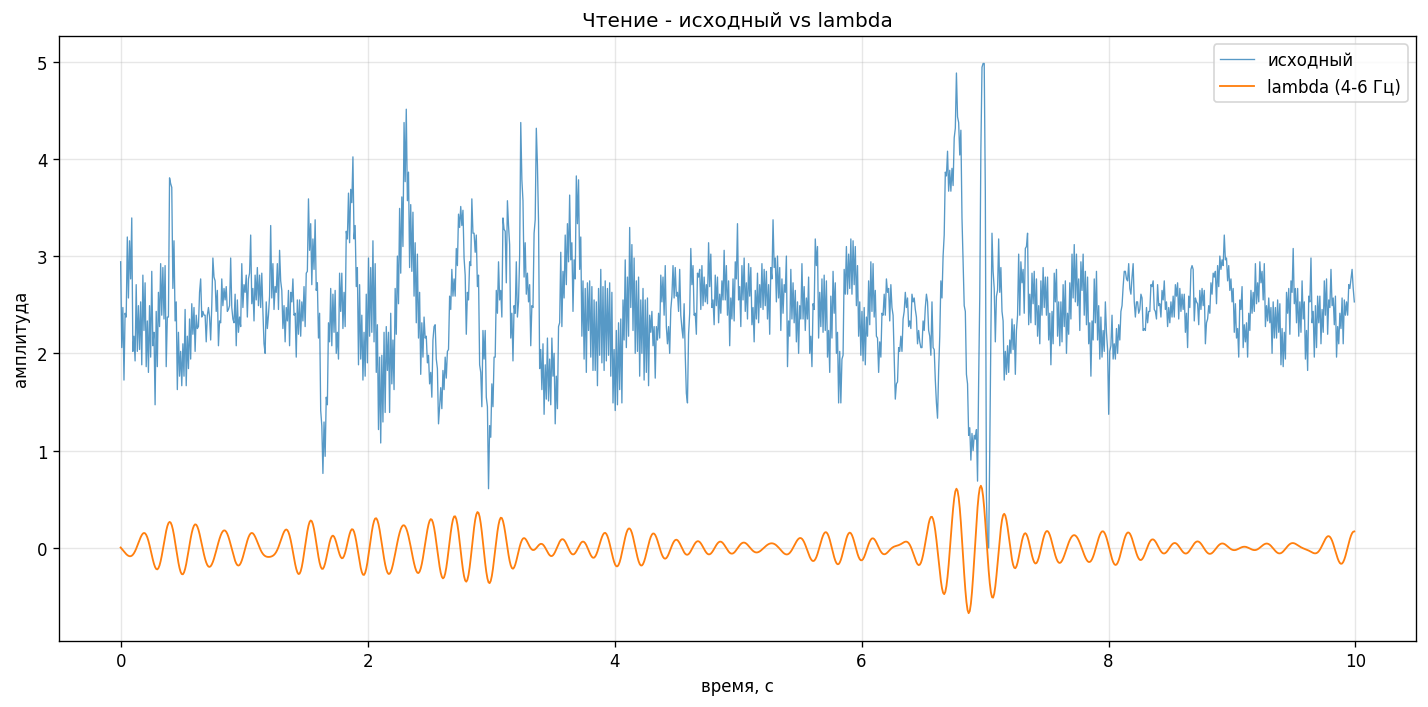

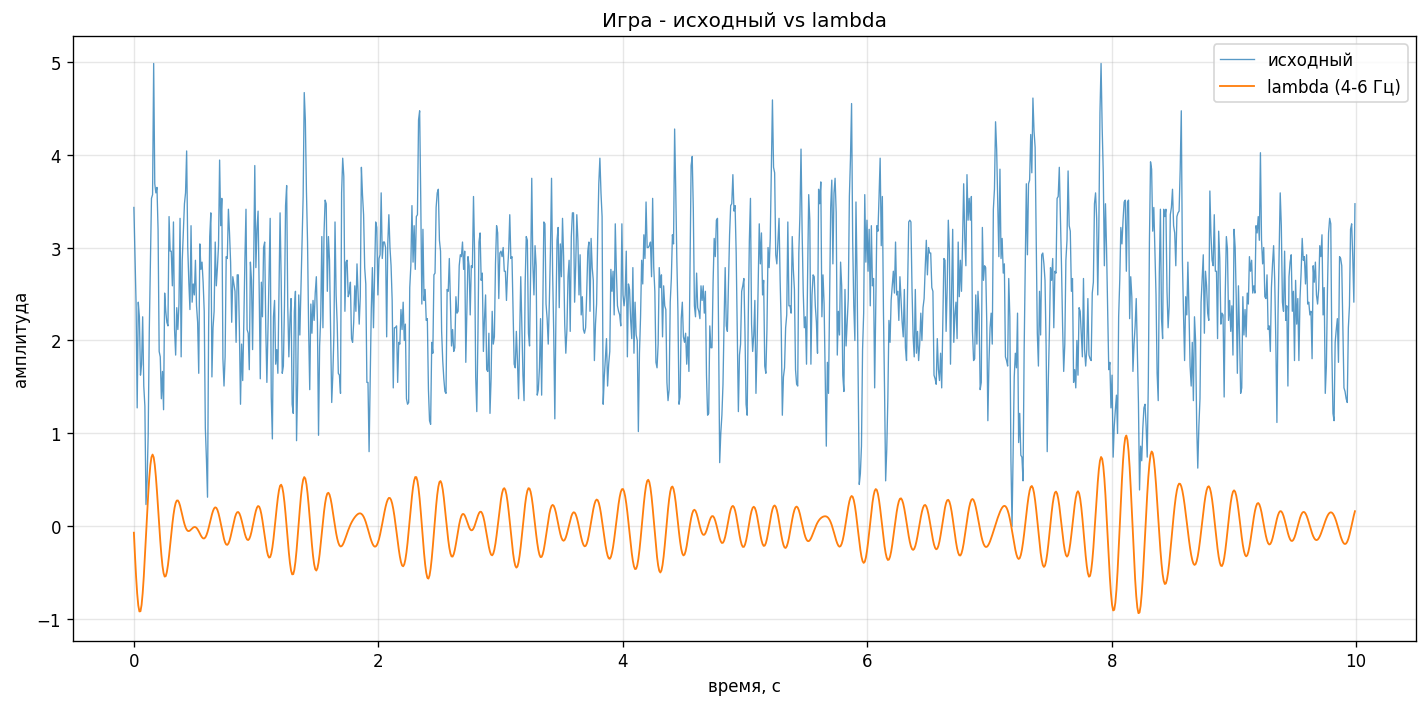

,условие,мощность_lambda,относительная_мощность,мощность_общая,средняя_амплитуда,std_амплитуда,макс_амплитуда
0,Просмотр видео,0.012561,0.187208,0.067096,0.071146,0.109919,1.087732
3,Игра,0.051248,0.163420,0.313598,0.167132,0.216389,1.062092
2,Чтение,0.005894,0.148141,0.039788,0.054247,0.075895,0.671709
1,Слежение глазами,0.003445,0.094794,0.036338,0.045458,0.060431,0.782814


In [ ]:
# Прогон
signals = {}
meta = {}

for title, fp in CONDITIONS:
    x, col, fs = read_signal_from_csv(fp, fs_fallback=fs_default, prefer_col=PREFER_COL)
    signals[title] = x
    meta[title] = {"fs": fs, "col": col}

# raw графики
for title, x in signals.items():
    plot_raw_blocks(x, meta[title]["fs"], title)

# PSD + таблица мощностей
spec_rows = []
psd_cache = {}

for title, x in signals.items():
    fs = meta[title]["fs"]
    powers = plot_psd_lambda(x, fs, title)
    psd_cache[title] = powers
    spec_rows.append({
        "условие": title,
        "мощность_lambda": powers["p_lambda"],
        "относительная_мощность": powers["p_lambda_rel"],
        "мощность_общая": powers["p_total"],
    })

results_df = pd.DataFrame(spec_rows)

# lambda по времени
lambda_rows = []
lambda_series = {}

for title, x in signals.items():
    fs = meta[title]["fs"]
    x_l, stats = plot_lambda_time(x, fs, title)
    lambda_series[title] = x_l
    lambda_rows.append({"условие": title, **stats})

lambda_df = pd.DataFrame(lambda_rows)

# объединение
comparison_df = (
    pd.merge(results_df, lambda_df, on="условие")
    .sort_values("относительная_мощность", ascending=False)
)
display(comparison_df)


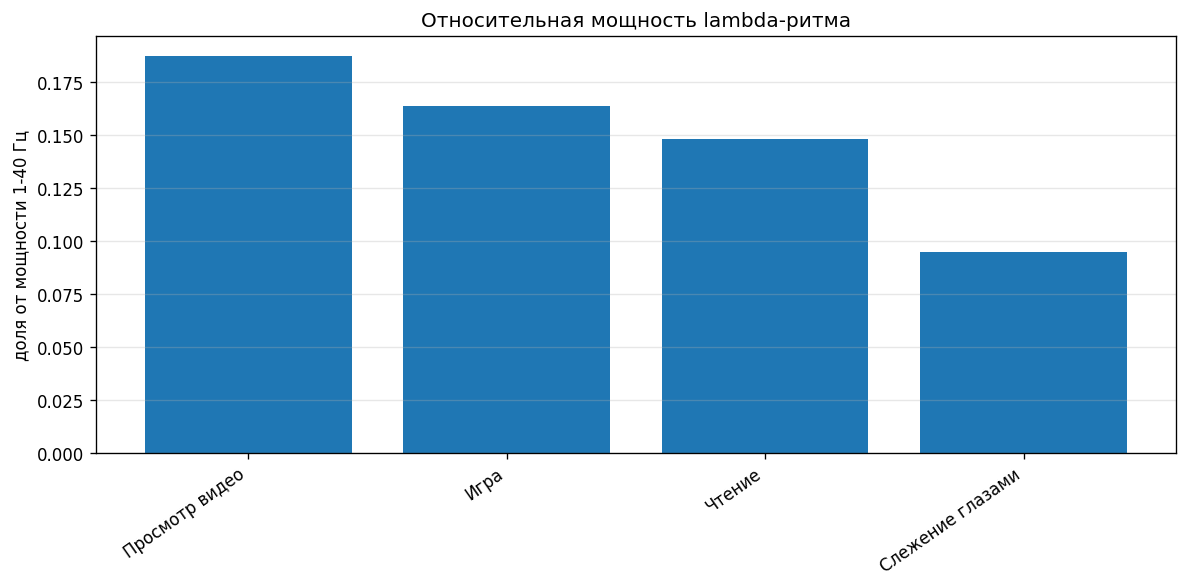

In [ ]:
# Итоговый график сравнения
fig, ax = plt.subplots(figsize=(10, 5))
conds = comparison_df["условие"].tolist()
xpos = np.arange(len(conds))

ax.bar(xpos, comparison_df["относительная_мощность"].to_numpy())
ax.set_xticks(xpos)
ax.set_xticklabels(conds, rotation=35, ha="right")
ax.set_title("Относительная мощность lambda-ритма")
ax.set_ylabel("доля от мощности 1-40 Гц")
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


## Итоговые выводы по данным


In [ ]:
# Вывод "макс/мин"
max_idx = int(comparison_df["относительная_мощность"].idxmax())
min_idx = int(comparison_df["относительная_мощность"].idxmin())

print("Максимальная мощность lambda-ритма наблюдается при:")
print(f"   {comparison_df.loc[max_idx, 'условие']}")
print(f"   относительная мощность: {comparison_df.loc[max_idx, 'относительная_мощность']:.4f}")

print("Минимальная мощность lambda-ритма наблюдается при:")
print(f"   {comparison_df.loc[min_idx, 'условие']}")
print(f"   относительная мощность: {comparison_df.loc[min_idx, 'относительная_мощность']:.4f}")


Максимальная мощность lambda-ритма наблюдается при:
   Просмотр видео
   относительная мощность: 0.1872
Минимальная мощность lambda-ритма наблюдается при:
   Слежение глазами
   относительная мощность: 0.0948


## Выводы

По доле лямбды получилось так:

1) Просмотр видео - 0.1872 (максимум)  
2) Игра - 0.1634  
3) Чтение - 0.1481  
4) Слежение глазами - 0.0948 (минимум)

Лямбду обычно связывают с зрительной нагрузкой и движениями глаз (особенно когда есть смена взгляда/фиксации).

Просмотр видео логично дает высокую лямбду: картинка меняется, взгляд постоянно перестраивается - лямбда может усиливаться. Чтение и игра - средний уровень: движения глаз есть, но они более однотипные, и там и там нужно читать текст, но в игре (в визуальной новелле) были еще иллюстрации и чаще менялась картинка. Слежение глазами вышло самым низким - там было больше плавного слежения (без частых "скачков" взгляда).

Таким образом, самая выраженная лямбда-активность - при просмотре видео, самая слабая - при слежении глазами.
